In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm.auto import tqdm

sys.path.insert(0, str((Path(".").resolve().parent / "shared")))
sys.path.insert(0, str(Path(".").resolve().parent.parent / "provided"))

from constants import FIGURES_PATH, CAPTIONS_PATH, TABLES_PATH, BANDS_PATH
from pgf_utils import configure_screen, configure_pgf, figure_inches, save_pgf, save_caption, save_table, apply_figure_style
from muscle_selection_freq_sweep import (
    NOTEBOOK_GITHUB_URL,
    _trial_job,
    find_bands,
    make_muscle_selection_freq_sweep_figure,
    make_muscle_selection_table,
)

In [2]:
# ── Constants ─────────────────────────────────────────────────────────────────
SEED        = 0
N_SWEEP     = 512                  # number of sweep frequencies
FREQ_MIN    = 0.03                 # cyc/step  (ω_min ≈ 0.19 rad/step)
FREQ_MAX    = 0.42                 # cyc/step  (ω_max ≈ 2.64 rad/step)
T_TRIAL     = 1200                 # total steps per trial
T_WARMUP    = 300                  # discard initial transient / burnin
AMPLITUDE   = 0.45                 # sinusoidal amplitude (open-loop)
OFFSET      = 0.5                  # DC offset (open-loop)
MAX_DELTA   = 0.3                  # max |Δangle| per step before treating as IK artifact
SMOOTH_WIN  = 5                    # moving-average window (samples) for display

# Open-loop channel conditions: (label, u0_scale, u1_scale)
CHANNELS = [
    ("$u_0$ only", 1.0, 0.0),
    ("$u_1$ only", 0.0, 1.0),
    ("both", 1.0, 1.0),
]

TRIAL_KW = dict(
    offset=OFFSET, amplitude=AMPLITUDE,
    t_trial=T_TRIAL, t_warmup=T_WARMUP, max_delta=MAX_DELTA,
)

In [3]:
# ── Sweep ─────────────────────────────────────────────────────────────────────
# Geometric spacing over [FREQ_MIN, FREQ_MAX] — finer resolution at low
# frequencies where shoulder bands live, matching archive identification method.
sweep_freqs = np.geomspace(FREQ_MIN, FREQ_MAX, N_SWEEP)
n_channels  = len(CHANNELS)

jobs = [
    (ci, fi, float(freq), float(u0), float(u1), SEED)
    for ci, (_, u0, u1) in enumerate(CHANNELS)
    for fi, freq in enumerate(sweep_freqs)
]
print(f"{len(jobs)} trials  ({n_channels} channel conditions × {N_SWEEP} freqs × 1 seed)")

1536 trials  (3 channel conditions × 512 freqs × 1 seed)


In [4]:
# ── Simulation ────────────────────────────────────────────────────────────────
results = np.zeros((n_channels, N_SWEEP, 2))  # [channel, freq, (sh, el)]

with tqdm(total=len(jobs), desc="frequency sweep") as pbar:
    for ci, fi, dsh, del_ in Parallel(n_jobs=-1, return_as="generator_unordered")(
        delayed(_trial_job)(*job, **TRIAL_KW) for job in jobs
    ):
        results[ci, fi, 0] = dsh
        results[ci, fi, 1] = del_
        pbar.update(1)

frequency sweep:   0%|          | 0/1536 [00:00<?, ?it/s]

Identified bands:
  S$+$    ω* = 0.426 rad/step  (f* = 0.0678 cyc/step)
  S$-$    ω* = 0.780 rad/step  (f* = 0.1241 cyc/step)
  E$+$    ω* = 1.301 rad/step  (f* = 0.2070 cyc/step)
  E$-$    ω* = 1.946 rad/step  (f* = 0.3097 cyc/step)


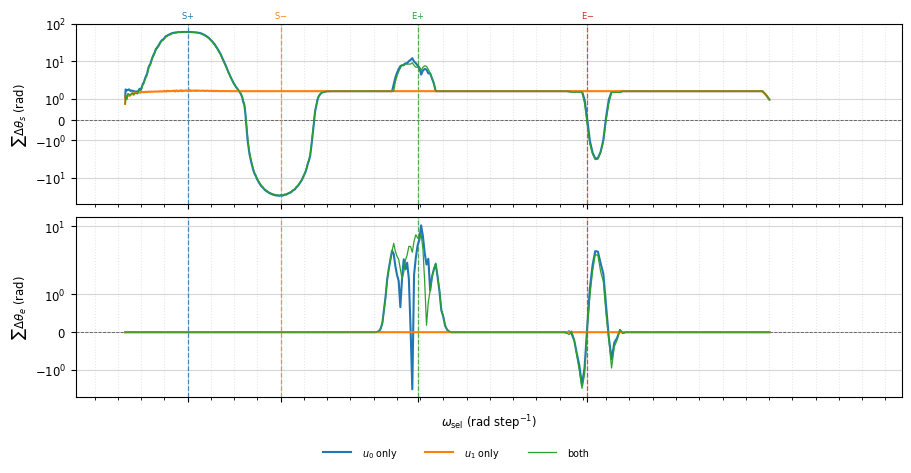

In [5]:
# ── Band identification and display ───────────────────────────────────────────
ch0 = 0  # u0 open-loop for band identification
bands = find_bands(sweep_freqs, results[ch0, :, 0], results[ch0, :, 1])

print("Identified bands:")
for freq, label, colour in bands:
    print(f"  {label:6s}  ω* = {2*np.pi*freq:.3f} rad/step  (f* = {freq:.4f} cyc/step)")

channel_labels = [lbl for lbl, *_ in CHANNELS]

configure_screen()
fig = make_muscle_selection_freq_sweep_figure(
    sweep_freqs, results,
    channel_labels=channel_labels,
    bands=bands,
    figsize=(9, 5),
    smooth_window=SMOOTH_WIN,
)
apply_figure_style(fig)
plt.show()

In [6]:
# ── Save bands ────────────────────────────────────────────────────────────────
import numpy as np
BANDS_PATH.parent.mkdir(parents=True, exist_ok=True)
np.savez(
    BANDS_PATH,
    freqs=np.array([f for f, _, _ in bands]),
    labels=np.array([lbl for _, lbl, _ in bands]),
    colours=np.array([c for _, _, c in bands]),
)
print(f"Bands saved to {BANDS_PATH}")

Bands saved to /Users/tahmidazam/Developer/gg4/data/bands.npz


In [7]:
# ── PGF export ────────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC  = 0.5
FIG_HEIGHT_FRAC = 0.3
configure_pgf()
fig = make_muscle_selection_freq_sweep_figure(
    sweep_freqs, results,
    channel_labels=channel_labels,
    bands=bands,
    figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC),
    smooth_window=SMOOTH_WIN,
)
apply_figure_style(fig)
save_pgf(fig, FIGURES_PATH / "muscle_selection_freq_sweep.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/muscle_selection_freq_sweep.pgf


In [8]:
# ── Caption ───────────────────────────────────────────────────────────────────
caption = (
    r"Open-loop sinusoidal drive (amplitude $A="
    f"{AMPLITUDE}"
    r"$ about "
    f"{OFFSET}"
    r") applied to $u_0$ or $u_1$ independently at each of "
    f"{N_SWEEP}"
    r" log-spaced frequencies $\omega_\mathrm{sel} \in ["
    f"{2*np.pi*FREQ_MIN:.3f}"
    r", "
    f"{2*np.pi*FREQ_MAX:.3f}"
    r"]$ rad\,step\textsuperscript{--1}. "
    r"Top: signed cumulative shoulder displacement $\sum\Delta\theta_s$; "
    r"bottom: cumulative elbow displacement $\sum\Delta\theta_e$, each summed over a "
    f"{T_TRIAL - T_WARMUP}"
    r"-step post-warmup window (symlog, linear threshold $\pm 1$ rad; "
    f"{SMOOTH_WIN}"
    r"-sample moving average). "
    r"Vertical lines mark the four bands, located on the $u_0$ response by peak "
    r"displacement (S$\pm$) and peak elbow selectivity "
    r"$|\Delta\theta_e|/(|\Delta\theta_e|+|\Delta\theta_s|)$ (E$\pm$)."
)
save_caption(CAPTIONS_PATH / "muscle_selection_freq_sweep.tex", caption, NOTEBOOK_GITHUB_URL)
print(caption)


Saved caption to /Users/tahmidazam/Developer/gg4/captions/muscle_selection_freq_sweep.tex
Open-loop sinusoidal drive (amplitude $A=0.45$ about 0.5) applied to $u_0$ or $u_1$ independently at each of 512 log-spaced frequencies $\omega_\mathrm{sel} \in [0.188, 2.639]$ rad\,step\textsuperscript{--1}. Top: signed cumulative shoulder displacement $\sum\Delta\theta_s$; bottom: cumulative elbow displacement $\sum\Delta\theta_e$, each summed over a 900-step post-warmup window (symlog, linear threshold $\pm 1$ rad; 5-sample moving average). Vertical lines mark the four bands, located on the $u_0$ response by peak displacement (S$\pm$) and peak elbow selectivity $|\Delta\theta_e|/(|\Delta\theta_e|+|\Delta\theta_s|)$ (E$\pm$).


In [9]:
# ── Table export ──────────────────────────────────────────────────────────────
WEIGHTS_PATH = Path(".").resolve().parent.parent / "provided" / "neural_activity_to_muscle_weights.npz"
tabular = make_muscle_selection_table(bands, WEIGHTS_PATH)
TABLES_PATH.mkdir(parents=True, exist_ok=True)
save_table(TABLES_PATH / "muscle_selection_freq_sweep.tex", tabular, NOTEBOOK_GITHUB_URL)
print(tabular)

Saved table to /Users/tahmidazam/Developer/gg4/tables/muscle_selection_freq_sweep.tex
\begin{tabular}{lSSS}
\toprule
  Muscle & {$\omega^*_\mathrm{true}$~(rad\,step\textsuperscript{--1})} & {$\omega^*_\mathrm{rec}$~(rad\,step\textsuperscript{--1})} & {$\Delta\omega$~(rad\,step\textsuperscript{--1})} \\
\midrule
  S$+$ & 0.4378 & 0.4263 & -0.0115 \\
  S$-$ & 0.7854 & 0.7800 & -0.0054 \\
  E$+$ & 1.2875 & 1.3006 & +0.0131 \\
  E$-$ & 1.9764 & 1.9458 & -0.0306 \\
\bottomrule
\end{tabular}


In [10]:
# ── Table caption ─────────────────────────────────────────────────────────────
table_caption = (
    r"True bandpass-filter centre frequencies $\omega^*_\mathrm{true}$ (from the "
    r"\BMI weights) against the values $\omega^*_\mathrm{rec}$ recovered by the "
    r"open-loop sweep (\autoref{fig:muscle_selection_freq_sweep}); "
    r"$\Delta\omega = \omega^*_\mathrm{rec} - \omega^*_\mathrm{true}$. "
    r"Rows are ordered by ascending frequency: shoulder flexion (S$+$), shoulder "
    r"extension (S$-$), elbow flexion (E$+$), elbow extension (E$-$)."
)
save_caption(CAPTIONS_PATH / "muscle_selection_freq_sweep_table.tex", table_caption, NOTEBOOK_GITHUB_URL)
print(table_caption)


Saved caption to /Users/tahmidazam/Developer/gg4/captions/muscle_selection_freq_sweep_table.tex
True bandpass-filter centre frequencies $\omega^*_\mathrm{true}$ (from the \BMI weights) against the values $\omega^*_\mathrm{rec}$ recovered by the open-loop sweep (\autoref{fig:muscle_selection_freq_sweep}); $\Delta\omega = \omega^*_\mathrm{rec} - \omega^*_\mathrm{true}$. Rows are ordered by ascending frequency: shoulder flexion (S$+$), shoulder extension (S$-$), elbow flexion (E$+$), elbow extension (E$-$).
